<p style="margin: 5px 0 0 0; color: #666;"><em>Desarrollado con Claude - Anthropic</em></p>

# 4. Análisis de Datos con Pandas

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl

print(f"Pandas versión: {pd.__version__}")

Pandas versión: 3.0.0


## Introducción a Pandas

### ¿Qué es?

**Pandas** es la librería más utilizada para análisis y manipulación de datos en Python. Proporciona dos estructuras de datos principales — `Series` (1D) y `DataFrame` (2D) — que permiten cargar, explorar, limpiar, transformar y analizar datos tabulares de forma eficiente e intuitiva. Está construida sobre NumPy y es la herramienta central del ecosistema de ciencia de datos en Python.

**Conceptos clave de Pandas:**

| Concepto | Descripción | Ejemplo |
|---|---|---|
| **Series** | Array 1D con índice etiquetado | `pd.Series([10, 20, 30])` |
| **DataFrame** | Tabla 2D con filas y columnas etiquetadas | `pd.DataFrame({'col': [1,2,3]})` |
| **Importación/Exportación** | Lectura y escritura de múltiples formatos | CSV, Excel, JSON, SQL |
| **Selección y Filtrado** | Acceso a subconjuntos de datos | `loc`, `iloc`, filtros booleanos |
| **GroupBy** | Agrupación y agregación por categorías | `df.groupby('col').sum()` |
| **Merge/Join** | Combinación de DataFrames | `pd.merge()`, `pd.concat()` |
| **Pivot Tables** | Tablas dinámicas y reshape | `pd.pivot_table()`, `melt()` |
| **Series Temporales** | Manejo de datos con fechas | `resample()`, `rolling()` |

### ¿Para qué sirve?

Pandas sirve para:

- **Cargar datos desde múltiples fuentes** como CSV, Excel, JSON, SQL y APIs en una sola línea de código
- **Explorar datasets rápidamente** con métodos como `info()`, `describe()`, `head()` y `value_counts()`
- **Filtrar, seleccionar y transformar datos** usando sintaxis intuitiva similar a SQL
- **Agrupar y agregar datos** para calcular estadísticas por categorías (ventas por producto, promedios por región)
- **Combinar múltiples tablas** mediante merge, join y concatenación, como en bases de datos relacionales
- **Manejar series temporales** con funciones de resample, rolling y componentes de fecha
- **Preparar datos para visualización y modelado** integrándose con matplotlib, seaborn y scikit-learn

### ¿Cómo se usa?

En las secciones siguientes, abordaremos las estructuras de datos de Pandas, importación/exportación, exploración, selección y filtrado, manejo de faltantes, transformaciones, agrupaciones, combinaciones, reshape y series temporales, culminando con un ejercicio práctico integrador.

## 1. Series y DataFrames

### ¿Qué es?

**Series** y **DataFrames** son las dos estructuras de datos fundamentales de Pandas. Una `Series` es un array unidimensional con índice etiquetado (similar a un diccionario ordenado o una columna de una tabla), mientras que un `DataFrame` es una estructura tabular bidimensional con filas y columnas etiquetadas (similar a una hoja de cálculo o tabla SQL).

**Comparación de estructuras:**

| Característica | Series | DataFrame |
|---|---|---|
| **Dimensiones** | 1D (una columna) | 2D (filas × columnas) |
| **Índice** | Un índice de filas | Índice de filas + nombres de columnas |
| **Creación** | `pd.Series(data, index)` | `pd.DataFrame(dict)` |
| **Acceso** | `serie['etiqueta']` o `serie[posición]` | `df['columna']`, `df.loc[]`, `df.iloc[]` |
| **Operaciones** | Vectorizadas (como NumPy) | Por columna o fila |

**Atributos principales del DataFrame:**

| Atributo | Descripción | Ejemplo |
|---|---|---|
| `.shape` | Dimensiones (filas, columnas) | `(100, 5)` |
| `.columns` | Nombres de las columnas | `['Producto', 'Precio']` |
| `.index` | Índice de las filas | `RangeIndex(0, 100)` |
| `.dtypes` | Tipos de dato por columna | `int64`, `object`, `float64` |

### ¿Para qué sirve?

Conocer Series y DataFrames sirve para:

- **Almacenar datos tabulares** de forma estructurada con etiquetas legibles en filas y columnas
- **Acceder a datos por etiqueta o posición** con flexibilidad usando `.loc[]` e `.iloc[]`
- **Operar sobre columnas individuales** (Series) o sobre la tabla completa (DataFrame)
- **Crear datasets desde múltiples fuentes** como diccionarios, listas, arrays de NumPy o archivos
- **Integrar con el ecosistema de datos** ya que la mayoría de librerías aceptan y devuelven DataFrames

### ¿Cómo se usa?

En el código siguiente, creamos una `Series` de ventas mensuales con índice personalizado y un `DataFrame` desde un diccionario, inspeccionando sus atributos de forma, columnas e índice.

In [6]:
# SERIES - Array unidimensional con índice
print("=" * 60)
print("PANDAS SERIES")
print("=" * 60)

# Crear serie desde lista
ventas = pd.Series([1000, 1500, 1200, 1800, 2000], 
                   index=['Ene', 'Feb', 'Mar', 'Abr', 'May'],
                   name='Ventas')

print(f"\nSerie de ventas:\n{ventas}")
print(f"\nAcceso por índice: ventas['Mar'] = {ventas['Mar']}")
print(f"Acceso por posición: ventas.iloc[2] = {ventas.iloc[2]}")
print(f"\nOperaciones: ventas * 1.1 =\n{ventas * 1.1}")

# DATAFRAME - Estructura tabular 2D
print("\n" + "=" * 60)
print("PANDAS DATAFRAME")
print("=" * 60)

# Crear DataFrame desde diccionario
df = pd.DataFrame({
    'Producto': ['Laptop', 'Mouse', 'Teclado', 'Monitor', 'Webcam'],
    'Precio': [1200, 25, 75, 300, 80],
    'Stock': [15, 150, 80, 30, 45],
    'Categoria': ['Computadoras', 'Periféricos', 'Periféricos', 'Computadoras', 'Periféricos']
})

print(f"\nDataFrame:\n{df}")
print(f"\nForma: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
print(f"Índice: {df.index.tolist()}")

PANDAS SERIES

Serie de ventas:
Ene    1000
Feb    1500
Mar    1200
Abr    1800
May    2000
Name: Ventas, dtype: int64

Acceso por índice: ventas['Mar'] = 1200
Acceso por posición: ventas.iloc[2] = 1200

Operaciones: ventas * 1.1 =
Ene    1100.0
Feb    1650.0
Mar    1320.0
Abr    1980.0
May    2200.0
Name: Ventas, dtype: float64

PANDAS DATAFRAME

DataFrame:
  Producto  Precio  Stock     Categoria
0   Laptop    1200     15  Computadoras
1    Mouse      25    150   Periféricos
2  Teclado      75     80   Periféricos
3  Monitor     300     30  Computadoras
4   Webcam      80     45   Periféricos

Forma: (5, 4)
Columnas: ['Producto', 'Precio', 'Stock', 'Categoria']
Índice: [0, 1, 2, 3, 4]


## 2. Importación y Exportación de Datos

### ¿Qué es?

La **importación y exportación de datos** es el proceso de leer datos desde archivos externos hacia un DataFrame y de escribir DataFrames a archivos en distintos formatos. Pandas soporta una amplia variedad de formatos de forma nativa, lo que facilita la interoperabilidad con otras herramientas.

**Formatos soportados:**

| Formato | Leer | Escribir | Uso típico |
|---|---|---|---|
| **CSV** | `pd.read_csv()` | `df.to_csv()` | Archivos de texto delimitados |
| **Excel** | `pd.read_excel()` | `df.to_excel()` | Hojas de cálculo (.xlsx) |
| **JSON** | `pd.read_json()` | `df.to_json()` | APIs web y datos semiestructurados |
| **SQL** | `pd.read_sql()` | `df.to_sql()` | Bases de datos relacionales |
| **Parquet** | `pd.read_parquet()` | `df.to_parquet()` | Big Data, formato columnar eficiente |

**Parámetros comunes de `read_csv()`:**

- `sep` → Delimitador (por defecto `,`)
- `header` → Fila con nombres de columnas
- `index_col` → Columna a usar como índice
- `encoding` → Codificación del archivo (`utf-8`, `latin1`)
- `parse_dates` → Columnas a convertir a fecha automáticamente

### ¿Para qué sirve?

La importación y exportación de datos sirve para:

- **Cargar datos reales** desde archivos CSV, Excel o bases de datos para su análisis
- **Integrar datos de múltiples fuentes** leyendo desde distintos formatos en un solo flujo
- **Exportar resultados procesados** para compartir con otros equipos o herramientas
- **Preservar el trabajo realizado** guardando DataFrames limpios y transformados
- **Automatizar pipelines** de lectura y escritura en procesos ETL

### ¿Cómo se usa?

En el código siguiente, creamos un DataFrame de ventas y lo exportamos a CSV, Excel y JSON, luego lo importamos de vuelta desde cada formato verificando que los datos se preservan correctamente.

In [10]:
# Crear datos de ejemplo para demostración
datos_ventas = pd.DataFrame({
    'Fecha': pd.date_range('2024-01-01', periods=10),
    'Producto': ['Laptop', 'Mouse', 'Teclado', 'Monitor', 'Webcam'] * 2,
    'Cantidad': [2, 5, 3, 1, 4, 1, 8, 2, 2, 3],
    'Precio': [1200, 25, 75, 300, 80, 1200, 25, 75, 300, 80],
    'Region': ['Norte', 'Sur', 'Este', 'Oeste', 'Centro'] * 2
})

datos_ventas['Total'] = datos_ventas['Cantidad'] * datos_ventas['Precio']

print("=" * 60)
print("EXPORTAR E IMPORTAR DATOS")
print("=" * 60)

# Exportar a CSV
datos_ventas.to_csv('ventas_ejemplo.csv', index=False)
print("\n✓ Datos exportados a CSV")

# Exportar a Excel
datos_ventas.to_excel('ventas_ejemplo.xlsx', index=False, engine='openpyxl')
print("✓ Datos exportados a Excel")

# Exportar a JSON
datos_ventas.to_json('ventas_ejemplo.json', orient='records', indent=2)
print("✓ Datos exportados a JSON")

# Importar desde CSV
df_csv = pd.read_csv('ventas_ejemplo.csv')
print(f"\n✓ Datos importados desde CSV ({df_csv.shape[0]} filas)")

# Importar desde Excel
df_excel = pd.read_excel('ventas_ejemplo.xlsx', engine='openpyxl')
print(f"✓ Datos importados desde Excel ({df_excel.shape[0]} filas)")

# Importar desde JSON
df_json = pd.read_json('ventas_ejemplo.json')
print(f"✓ Datos importados desde JSON ({df_json.shape[0]} filas)")

print(f"\nPrimeras filas del CSV:\n{df_csv.head(3)}")

EXPORTAR E IMPORTAR DATOS

✓ Datos exportados a CSV
✓ Datos exportados a Excel
✓ Datos exportados a JSON

✓ Datos importados desde CSV (10 filas)
✓ Datos importados desde Excel (10 filas)
✓ Datos importados desde JSON (10 filas)

Primeras filas del CSV:
        Fecha Producto  Cantidad  Precio Region  Total
0  2024-01-01   Laptop         2    1200  Norte   2400
1  2024-01-02    Mouse         5      25    Sur    125
2  2024-01-03  Teclado         3      75   Este    225


C:\Users\ingen\AppData\Local\Temp\ipykernel_14068\348222226.py:25: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  datos_ventas.to_json('ventas_ejemplo.json', orient='records', indent=2)


## 3. Exploración de Datos

### ¿Qué es?

La **exploración de datos** es el primer paso tras cargar un dataset: consiste en obtener una visión general de su estructura, tipos de datos, estadísticas descriptivas, distribución de valores y presencia de datos faltantes. Pandas proporciona métodos rápidos que resumen toda esta información en pocas líneas.

**Métodos de exploración principales:**

| Método | Descripción | Información que devuelve |
|---|---|---|
| `info()` | Resumen del DataFrame | Columnas, tipos, no-nulos, memoria |
| `describe()` | Estadísticas descriptivas | Media, std, min, max, cuartiles |
| `head(n)` / `tail(n)` | Primeras / últimas n filas | Vista rápida de los datos |
| `shape` | Dimensiones | `(filas, columnas)` |
| `dtypes` | Tipos de dato por columna | `int64`, `object`, `float64` |
| `value_counts()` | Conteo de valores únicos | Frecuencia de cada categoría |
| `isnull().sum()` | Conteo de nulos por columna | Cantidad de valores faltantes |

### ¿Para qué sirve?

La exploración de datos sirve para:

- **Entender la estructura del dataset** antes de cualquier análisis o transformación
- **Detectar problemas de calidad** como tipos incorrectos, valores faltantes o distribuciones inesperadas
- **Obtener estadísticas rápidas** (media, mediana, desviación) sin escribir cálculos manuales
- **Conocer la distribución de variables categóricas** mediante conteos de frecuencia
- **Dimensionar el dataset** para evaluar si requiere optimización de memoria o muestreo
- **Documentar el estado inicial** de los datos como referencia para el proceso de limpieza

### ¿Cómo se usa?

En el código siguiente, creamos un dataset de 100 registros y aplicamos `info()`, `describe()`, `head()`, `tail()`, `value_counts()` e `isnull().sum()` para obtener una visión completa de su estructura y contenido.

In [11]:
# Crear dataset más completo
np.random.seed(42)
df = pd.DataFrame({
    'Producto': ['Laptop', 'Mouse', 'Teclado', 'Monitor', 'Webcam'] * 20,
    'Ventas': np.random.randint(50, 200, 100),
    'Precio': [1200, 25, 75, 300, 80] * 20,
    'Region': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], 100),
    'Mes': np.random.choice(['Ene', 'Feb', 'Mar', 'Abr'], 100)
})

df['Ingresos'] = df['Ventas'] * df['Precio']

print("=" * 60)
print("EXPLORACIÓN DE DATOS")
print("=" * 60)

# info() - Información general
print("\n1. INFO - Información del DataFrame:")
print(df.info())

# describe() - Estadísticas descriptivas
print("\n2. DESCRIBE - Estadísticas numéricas:")
print(df.describe())

# head() y tail()
print("\n3. HEAD - Primeras 5 filas:")
print(df.head())

print("\n4. TAIL - Últimas 3 filas:")
print(df.tail(3))

# Valores únicos y conteos
print("\n5. VALUE_COUNTS - Conteo de productos:")
print(df['Producto'].value_counts())

# Información de faltantes
print("\n6. ISNULL - Valores faltantes:")
print(df.isnull().sum())

EXPLORACIÓN DE DATOS

1. INFO - Información del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Producto  100 non-null    str  
 1   Ventas    100 non-null    int32
 2   Precio    100 non-null    int64
 3   Region    100 non-null    str  
 4   Mes       100 non-null    str  
 5   Ingresos  100 non-null    int64
dtypes: int32(1), int64(2), str(3)
memory usage: 5.7 KB
None

2. DESCRIBE - Estadísticas numéricas:
           Ventas       Precio       Ingresos
count  100.000000   100.000000     100.000000
mean   119.950000   336.000000   40348.450000
std     42.128321   444.533577   58474.530244
min     51.000000    25.000000    1275.000000
25%     86.750000    75.000000    6237.500000
50%    117.000000    80.000000   11475.000000
75%    153.000000   300.000000   47325.000000
max    199.000000  1200.000000  234000.000000

3. HEAD - Primeras 5 filas:
  Producto

## 4. Selección y Filtrado de Datos

### ¿Qué es?

La **selección y filtrado** son las operaciones para acceder a subconjuntos específicos de un DataFrame: columnas individuales, rangos de filas, combinaciones de filas y columnas, o registros que cumplan condiciones lógicas. Pandas ofrece múltiples métodos complementarios para cubrir cualquier necesidad de acceso.

**Métodos de selección:**

| Método | Tipo de acceso | Ejemplo |
|---|---|---|
| `df['col']` | Columna por nombre | `df['Ventas']` |
| `df[['col1','col2']]` | Múltiples columnas | `df[['Ventas','Precio']]` |
| `df.loc[fila, col]` | Por etiqueta (nombre) | `df.loc[0:4, 'Ventas']` |
| `df.iloc[fila, col]` | Por posición (entero) | `df.iloc[0:5, 0:3]` |
| `df[condición]` | Filtrado booleano | `df[df['Ventas'] > 150]` |
| `df.isin()` | Pertenencia a lista | `df[df['col'].isin([1,2])]` |
| `df.query()` | Sintaxis tipo SQL | `df.query('Ventas > 150')` |

**Diferencia clave entre `loc` e `iloc`:**

- `loc` → Acceso por **etiqueta** (incluye el extremo final): `df.loc[0:4]` devuelve filas 0, 1, 2, 3, 4
- `iloc` → Acceso por **posición** (excluye el extremo final): `df.iloc[0:5]` devuelve filas 0, 1, 2, 3, 4

### ¿Para qué sirve?

La selección y filtrado de datos sirve para:

- **Acceder a columnas específicas** para análisis o visualización de variables individuales
- **Filtrar registros por condiciones** como rangos, valores exactos o pertenencia a listas
- **Combinar múltiples condiciones** con operadores `&` (AND) y `|` (OR) para filtros complejos
- **Extraer subconjuntos para análisis parcial** por región, periodo, categoría u otro criterio
- **Preparar datos para funciones** que requieren columnas o subsets específicos
- **Usar sintaxis tipo SQL** con `query()` para consultas legibles y concisas

### ¿Cómo se usa?

En el código siguiente, seleccionamos columnas individuales y múltiples, usamos `loc` e `iloc` para rangos, aplicamos filtrado booleano con una y múltiples condiciones, `isin()` para pertenencia y `query()` con sintaxis tipo SQL.

In [12]:
print("=" * 60)
print("SELECCIÓN Y FILTRADO")
print("=" * 60)

# Selección de columnas
print("\n1. Seleccionar una columna:")
print(df['Producto'].head())

print("\n2. Seleccionar múltiples columnas:")
print(df[['Producto', 'Ventas', 'Ingresos']].head())

# loc - Acceso por etiqueta
print("\n3. LOC - Selección por etiqueta:")
print(df.loc[0:4, ['Producto', 'Ventas']])

# iloc - Acceso por posición
print("\n4. ILOC - Selección por posición:")
print(df.iloc[0:5, 0:3])

# Filtrado booleano
print("\n5. FILTRADO - Ventas > 150:")
print(df[df['Ventas'] > 150].head())

print("\n6. FILTRADO - Múltiples condiciones:")
filtro = (df['Ventas'] > 150) & (df['Region'] == 'Norte')
print(df[filtro].head())

print("\n7. ISIN - Productos específicos:")
print(df[df['Producto'].isin(['Laptop', 'Monitor'])].head())

# query() - Filtrado con sintaxis SQL-like
print("\n8. QUERY - Sintaxis SQL-like:")
print(df.query('Ventas > 150 and Region == "Norte"').head())

SELECCIÓN Y FILTRADO

1. Seleccionar una columna:
0     Laptop
1      Mouse
2    Teclado
3    Monitor
4     Webcam
Name: Producto, dtype: str

2. Seleccionar múltiples columnas:
  Producto  Ventas  Ingresos
0   Laptop     152    182400
1    Mouse     142      3550
2  Teclado      64      4800
3  Monitor     156     46800
4   Webcam     121      9680

3. LOC - Selección por etiqueta:
  Producto  Ventas
0   Laptop     152
1    Mouse     142
2  Teclado      64
3  Monitor     156
4   Webcam     121

4. ILOC - Selección por posición:
  Producto  Ventas  Precio
0   Laptop     152    1200
1    Mouse     142      25
2  Teclado      64      75
3  Monitor     156     300
4   Webcam     121      80

5. FILTRADO - Ventas > 150:
   Producto  Ventas  Precio Region  Mes  Ingresos
0    Laptop     152    1200    Sur  Abr    182400
3   Monitor     156     300  Norte  Ene     46800
6     Mouse     152      25   Este  Abr      3800
7   Teclado     171      75    Sur  Feb     12825
10   Laptop     166    1

## 5. Manejo de Datos Faltantes

### ¿Qué es?

El **manejo de datos faltantes** en Pandas consiste en detectar y tratar los valores `NaN` (Not a Number) o `None` presentes en un DataFrame. Pandas representa internamente los faltantes como `NaN` y proporciona métodos para detectarlos, eliminarlos o imputarlos con diferentes estrategias.

**Métodos principales:**

| Método | Descripción | Resultado |
|---|---|---|
| `isnull()` / `isna()` | Detectar valores nulos | Máscara booleana |
| `isnull().sum()` | Contar nulos por columna | Conteo de faltantes |
| `dropna()` | Eliminar filas/columnas con nulos | DataFrame sin NaN |
| `fillna(valor)` | Rellenar con valor fijo | NaN → valor dado |
| `fillna(media)` | Rellenar con estadístico | NaN → media/mediana |
| `interpolate()` | Interpolación lineal | NaN → valor estimado |
| `ffill()` | Forward fill (propagar anterior) | NaN → último valor válido |
| `bfill()` | Backward fill (propagar siguiente) | NaN → próximo valor válido |

### ¿Para qué sirve?

El manejo de datos faltantes sirve para:

- **Detectar la magnitud del problema** contando y visualizando los nulos antes de decidir el tratamiento
- **Eliminar registros incompletos** cuando la proporción de faltantes es baja y no introduce sesgo
- **Imputar con estadísticos** (media, mediana, moda) para conservar el tamaño del dataset
- **Interpolar valores** en series ordenadas donde los faltantes tienen un valor intermedio lógico
- **Propagar valores** hacia adelante o atrás en series temporales donde el último valor conocido es representativo
- **Preparar datos para modelos** que no aceptan valores nulos como entrada

### ¿Cómo se usa?

En el código siguiente, creamos un DataFrame con valores faltantes intencionales y aplicamos las estrategias: `dropna()`, `fillna()` con valor fijo y con media, `interpolate()`, forward fill y backward fill, comparando los resultados.

In [13]:
# Crear DataFrame con valores faltantes
df_faltantes = pd.DataFrame({
    'A': [1, 2, np.nan, 4, 5],
    'B': [10, np.nan, 30, np.nan, 50],
    'C': [100, 200, 300, 400, 500],
    'D': [np.nan, 'B', 'C', 'D', 'E']
})

print("=" * 60)
print("MANEJO DE DATOS FALTANTES")
print("=" * 60)

print("\nDataFrame original:")
print(df_faltantes)

print("\nValores faltantes por columna:")
print(df_faltantes.isnull().sum())

# dropna() - Eliminar filas con NaN
print("\n1. DROPNA - Eliminar filas con NaN:")
print(df_faltantes.dropna())

# fillna() - Rellenar con valor
print("\n2. FILLNA - Rellenar con 0:")
print(df_faltantes.fillna(0))

# Rellenar con media
print("\n3. FILLNA - Rellenar con media:")
df_filled = df_faltantes.copy()
df_filled['A'] = df_filled['A'].fillna(df_filled['A'].mean())
df_filled['B'] = df_filled['B'].fillna(df_filled['B'].mean())
print(df_filled)

# interpolate() - Interpolación
print("\n4. INTERPOLATE - Interpolación lineal:")
df_interpolado = df_faltantes.copy()
df_interpolado[['A', 'B']] = df_interpolado[['A', 'B']].interpolate()
print(df_interpolado)

# Forward fill
print("\n5. FFILL - Forward fill:")
print(df_faltantes.ffill())

# Backward fill
print("\n6. BFILL - Backward fill:")
print(df_faltantes.bfill())

MANEJO DE DATOS FALTANTES

DataFrame original:
     A     B    C    D
0  1.0  10.0  100  NaN
1  2.0   NaN  200    B
2  NaN  30.0  300    C
3  4.0   NaN  400    D
4  5.0  50.0  500    E

Valores faltantes por columna:
A    1
B    2
C    0
D    1
dtype: int64

1. DROPNA - Eliminar filas con NaN:
     A     B    C  D
4  5.0  50.0  500  E

2. FILLNA - Rellenar con 0:
     A     B    C  D
0  1.0  10.0  100  0
1  2.0   0.0  200  B
2  0.0  30.0  300  C
3  4.0   0.0  400  D
4  5.0  50.0  500  E

3. FILLNA - Rellenar con media:
     A     B    C    D
0  1.0  10.0  100  NaN
1  2.0  30.0  200    B
2  3.0  30.0  300    C
3  4.0  30.0  400    D
4  5.0  50.0  500    E

4. INTERPOLATE - Interpolación lineal:
     A     B    C    D
0  1.0  10.0  100  NaN
1  2.0  20.0  200    B
2  3.0  30.0  300    C
3  4.0  40.0  400    D
4  5.0  50.0  500    E

5. FFILL - Forward fill:
     A     B    C    D
0  1.0  10.0  100  NaN
1  2.0  10.0  200    B
2  2.0  30.0  300    C
3  4.0  30.0  400    D
4  5.0  50.0  500 

## 6. Transformación de Datos

### ¿Qué es?

La **transformación de datos** es el proceso de modificar, crear o reformatear columnas de un DataFrame para adaptarlas al análisis o modelado requerido. Pandas ofrece métodos como `apply()`, `map()` y `replace()` que permiten aplicar funciones, mapear valores y crear columnas calculadas de forma eficiente.

**Métodos principales de transformación:**

| Método | Descripción | Uso típico |
|---|---|---|
| `apply()` | Aplica función a columna o fila | Cálculos personalizados, lambdas |
| `map()` | Mapea valores según diccionario o función | Recodificar categorías |
| `replace()` | Reemplaza valores específicos | Corregir errores, renombrar |
| `pd.cut()` | Binning en intervalos equidistantes | Categorizar variables continuas |
| `pd.qcut()` | Binning por cuantiles | Categorizar por percentiles |
| Operaciones directas | Aritmética entre columnas | `df['C'] = df['A'] * df['B']` |

**Diferencia entre `apply()` y `map()`:**

- `apply()` → Acepta funciones complejas con lógica condicional, trabaja sobre Series o DataFrames completos
- `map()` → Optimizado para mapeo directo de valores (diccionario) o funciones simples, solo trabaja sobre Series

### ¿Para qué sirve?

La transformación de datos sirve para:

- **Crear nuevas columnas calculadas** a partir de operaciones entre columnas existentes
- **Recodificar variables categóricas** mapeando valores textuales a códigos o etiquetas diferentes
- **Aplicar funciones personalizadas** para transformar valores según reglas de negocio
- **Categorizar variables continuas** agrupándolas en rangos (bajo, medio, alto)
- **Normalizar valores** escalando columnas al rango [0, 1] o estandarizando
- **Corregir y estandarizar valores** reemplazando errores o formatos inconsistentes

### ¿Cómo se usa?

En el código siguiente, aplicamos `apply()` con lambda para calcular descuentos, `map()` para recodificar regiones, `replace()` para renombrar meses, `pd.cut()` para categorizar ingresos y normalización min-max para crear una columna escalada.

In [14]:
print("=" * 60)
print("TRANSFORMACIÓN DE DATOS")
print("=" * 60)

# apply() - Aplicar función a columna
print("\n1. APPLY - Calcular descuento 10%:")
df['PrecioConDescuento'] = df['Precio'].apply(lambda x: x * 0.9)
print(df[['Producto', 'Precio', 'PrecioConDescuento']].head())

# map() - Mapear valores
print("\n2. MAP - Mapear categorías:")
mapeo_region = {'Norte': 'N', 'Sur': 'S', 'Este': 'E', 'Oeste': 'O'}
df['RegionCodigo'] = df['Region'].map(mapeo_region)
print(df[['Region', 'RegionCodigo']].head())

# replace() - Reemplazar valores
print("\n3. REPLACE - Reemplazar valores:")
df_temp = df.copy()
df_temp['Mes'] = df_temp['Mes'].replace({'Ene': 'Enero', 'Feb': 'Febrero'})
print(df_temp[['Mes']].head())

# Crear nuevas columnas calculadas
print("\n4. Crear columnas calculadas:")
df['IngresosCategoria'] = pd.cut(df['Ingresos'], 
                                  bins=[0, 5000, 20000, 150000],
                                  labels=['Bajo', 'Medio', 'Alto'])
print(df[['Producto', 'Ingresos', 'IngresosCategoria']].head())

# applymap() - Aplicar función a todo el DataFrame (versión moderna: map)
print("\n5. Transformación múltiple:")
df['VentasNormalizadas'] = (df['Ventas'] - df['Ventas'].min()) / (df['Ventas'].max() - df['Ventas'].min())
print(df[['Ventas', 'VentasNormalizadas']].head())

TRANSFORMACIÓN DE DATOS

1. APPLY - Calcular descuento 10%:
  Producto  Precio  PrecioConDescuento
0   Laptop    1200              1080.0
1    Mouse      25                22.5
2  Teclado      75                67.5
3  Monitor     300               270.0
4   Webcam      80                72.0

2. MAP - Mapear categorías:
  Region RegionCodigo
0    Sur            S
1   Este            E
2   Este            E
3  Norte            N
4   Este            E

3. REPLACE - Reemplazar valores:
       Mes
0      Abr
1    Enero
2  Febrero
3    Enero
4  Febrero

4. Crear columnas calculadas:
  Producto  Ingresos IngresosCategoria
0   Laptop    182400               NaN
1    Mouse      3550              Bajo
2  Teclado      4800              Bajo
3  Monitor     46800              Alto
4   Webcam      9680             Medio

5. Transformación múltiple:
   Ventas  VentasNormalizadas
0     152            0.682432
1     142            0.614865
2      64            0.087838
3     156            0.709459
4

## 7. Agrupación y Agregación (GroupBy)

### ¿Qué es?

El método **`groupby()`** de Pandas implementa el patrón *split-apply-combine*: divide el DataFrame en grupos según una o más columnas, aplica una función de agregación a cada grupo y combina los resultados en un nuevo DataFrame. Es el equivalente a `GROUP BY` en SQL.

**Flujo split-apply-combine:**

```
DataFrame original → Split (por grupo) → Apply (función) → Combine (resultado)
```

**Métodos de agregación:**

| Método | Descripción | Ejemplo |
|---|---|---|
| `sum()` | Suma por grupo | `df.groupby('col').sum()` |
| `mean()` | Promedio por grupo | `df.groupby('col').mean()` |
| `count()` | Conteo por grupo | `df.groupby('col').count()` |
| `agg()` | Múltiples funciones a la vez | `agg({'col': ['sum', 'mean']})` |
| `transform()` | Devuelve resultado del mismo tamaño | Promedio del grupo para cada fila |
| `filter()` | Filtra grupos que cumplan condición | Grupos con más de N registros |

### ¿Para qué sirve?

La agrupación y agregación sirve para:

- **Calcular estadísticas por categoría** como ventas totales por producto, promedio por región, etc.
- **Aplicar múltiples funciones simultáneamente** con `agg()` para obtener resúmenes completos
- **Agrupar por múltiples columnas** para análisis cruzados (producto × región)
- **Agregar columnas contextuales** con `transform()` que añade el estadístico del grupo a cada fila
- **Filtrar grupos completos** con `filter()` según condiciones sobre el grupo (ej: grupos con más de N registros)
- **Crear resúmenes ejecutivos** con agregaciones nombradas para reportes claros

### ¿Cómo se usa?

En el código siguiente, agrupamos por producto y región, aplicamos `sum()`, `agg()` con múltiples funciones, agregaciones nombradas, `transform()` para añadir el promedio del grupo a cada fila y `filter()` para seleccionar grupos por tamaño.

In [15]:
print("=" * 60)
print("AGRUPACIÓN Y AGREGACIÓN")
print("=" * 60)

# Agrupar por una columna
print("\n1. Ventas totales por producto:")
print(df.groupby('Producto')['Ventas'].sum())

print("\n2. Múltiples agregaciones:")
print(df.groupby('Producto').agg({
    'Ventas': ['sum', 'mean', 'count'],
    'Ingresos': ['sum', 'mean']
}))

print("\n3. Agrupar por múltiples columnas:")
print(df.groupby(['Producto', 'Region'])['Ventas'].sum().head(10))

print("\n4. Agregaciones personalizadas:")
resumen = df.groupby('Producto').agg(
    VentasTotales=('Ventas', 'sum'),
    VentasPromedio=('Ventas', 'mean'),
    IngresosTotales=('Ingresos', 'sum'),
    NumTransacciones=('Ventas', 'count')
).round(2)
print(resumen)

print("\n5. Transformación dentro de grupos:")
df['VentasPromedioPorProducto'] = df.groupby('Producto')['Ventas'].transform('mean')
print(df[['Producto', 'Ventas', 'VentasPromedioPorProducto']].head())

print("\n6. Filtrar grupos:")
# Productos con más de 15 transacciones
productos_populares = df.groupby('Producto').filter(lambda x: len(x) > 15)
print(f"Productos con >15 transacciones: {productos_populares['Producto'].unique()}")

AGRUPACIÓN Y AGREGACIÓN

1. Ventas totales por producto:
Producto
Laptop     2395
Monitor    2434
Mouse      2368
Teclado    2479
Webcam     2319
Name: Ventas, dtype: int32

2. Múltiples agregaciones:
         Ventas               Ingresos           
            sum    mean count      sum       mean
Producto                                         
Laptop     2395  119.75    20  2874000  143700.00
Monitor    2434  121.70    20   730200   36510.00
Mouse      2368  118.40    20    59200    2960.00
Teclado    2479  123.95    20   185925    9296.25
Webcam     2319  115.95    20   185520    9276.00

3. Agrupar por múltiples columnas:
Producto  Region
Laptop    Este      643
          Norte     597
          Oeste     195
          Sur       960
Monitor   Este      734
          Norte     968
          Oeste     548
          Sur       184
Mouse     Este      827
          Norte     410
Name: Ventas, dtype: int32

4. Agregaciones personalizadas:
          VentasTotales  VentasPromedio  Ingre

## 8. Operaciones de Combinación

### ¿Qué es?

Las **operaciones de combinación** permiten unir dos o más DataFrames en uno solo, ya sea por columnas clave (como en SQL) o por concatenación. Son esenciales cuando los datos provienen de múltiples fuentes o tablas que necesitan integrarse para el análisis.

**Métodos principales:**

| Método | Descripción | Equivalente SQL |
|---|---|---|
| `pd.merge()` | Une por columna(s) clave | `JOIN` |
| `pd.concat()` | Concatena vertical u horizontalmente | `UNION` / columnas lado a lado |
| `df.join()` | Une por índice | `JOIN` por índice |

**Tipos de merge (join):**

| Tipo | `how=` | Descripción |
|---|---|---|
| **Inner** | `'inner'` | Solo filas con clave en ambos DataFrames |
| **Left** | `'left'` | Todas las filas del izquierdo + coincidencias del derecho |
| **Right** | `'right'` | Todas las filas del derecho + coincidencias del izquierdo |
| **Outer** | `'outer'` | Todas las filas de ambos, NaN donde no hay coincidencia |

**Parámetros de `concat()`:**

- `axis=0` → Concatenación vertical (apilar filas)
- `axis=1` → Concatenación horizontal (añadir columnas)
- `ignore_index=True` → Resetear el índice resultante

### ¿Para qué sirve?

Las operaciones de combinación sirven para:

- **Integrar datos de múltiples tablas** relacionadas por una clave común (ID, nombre, fecha)
- **Replicar operaciones de SQL** como INNER JOIN, LEFT JOIN y UNION desde Python
- **Concatenar datasets** del mismo formato procedentes de distintos archivos o periodos
- **Añadir columnas de contexto** combinando tablas de hechos con tablas de dimensiones
- **Detectar registros sin coincidencia** usando LEFT/RIGHT JOIN y buscando NaN
- **Unir por índice** cuando los DataFrames comparten un índice significativo

### ¿Cómo se usa?

En el código siguiente, creamos tablas de productos y ventas, las unimos con `merge()` (inner y left join), concatenamos DataFrames vertical y horizontalmente con `concat()`, y usamos `join()` para unir por índice.

In [16]:
print("=" * 60)
print("OPERACIONES DE COMBINACIÓN")
print("=" * 60)

# Crear DataFrames de ejemplo
df_productos = pd.DataFrame({
    'ProductoID': [1, 2, 3, 4],
    'Nombre': ['Laptop', 'Mouse', 'Teclado', 'Monitor'],
    'Categoria': ['Computadoras', 'Periféricos', 'Periféricos', 'Computadoras']
})

df_ventas = pd.DataFrame({
    'VentaID': [101, 102, 103, 104, 105],
    'ProductoID': [1, 2, 1, 3, 2],
    'Cantidad': [2, 5, 1, 3, 4],
    'Precio': [1200, 25, 1200, 75, 25]
})

print("\nDataFrame Productos:")
print(df_productos)
print("\nDataFrame Ventas:")
print(df_ventas)

# MERGE - Inner join
print("\n1. MERGE (INNER JOIN):")
merge_inner = pd.merge(df_ventas, df_productos, on='ProductoID', how='inner')
print(merge_inner)

# MERGE - Left join
print("\n2. MERGE (LEFT JOIN):")
df_ventas_extra = df_ventas.copy()
df_ventas_extra.loc[5] = [106, 99, 1, 500]  # Producto que no existe
merge_left = pd.merge(df_ventas_extra, df_productos, on='ProductoID', how='left')
print(merge_left)

# CONCAT - Concatenar verticalmente
print("\n3. CONCAT (vertical):")
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})
concat_vertical = pd.concat([df1, df2], ignore_index=True)
print(concat_vertical)

# CONCAT - Concatenar horizontalmente
print("\n4. CONCAT (horizontal):")
df3 = pd.DataFrame({'C': [9, 10], 'D': [11, 12]})
concat_horizontal = pd.concat([df1, df3], axis=1)
print(concat_horizontal)

# JOIN - Usando índices
print("\n5. JOIN (usando índices):")
df_left = pd.DataFrame({'A': [1, 2]}, index=['a', 'b'])
df_right = pd.DataFrame({'B': [3, 4]}, index=['a', 'b'])
join_result = df_left.join(df_right)
print(join_result)

OPERACIONES DE COMBINACIÓN

DataFrame Productos:
   ProductoID   Nombre     Categoria
0           1   Laptop  Computadoras
1           2    Mouse   Periféricos
2           3  Teclado   Periféricos
3           4  Monitor  Computadoras

DataFrame Ventas:
   VentaID  ProductoID  Cantidad  Precio
0      101           1         2    1200
1      102           2         5      25
2      103           1         1    1200
3      104           3         3      75
4      105           2         4      25

1. MERGE (INNER JOIN):
   VentaID  ProductoID  Cantidad  Precio   Nombre     Categoria
0      101           1         2    1200   Laptop  Computadoras
1      102           2         5      25    Mouse   Periféricos
2      103           1         1    1200   Laptop  Computadoras
3      104           3         3      75  Teclado   Periféricos
4      105           2         4      25    Mouse   Periféricos

2. MERGE (LEFT JOIN):
   VentaID  ProductoID  Cantidad  Precio   Nombre     Categoria
0     

## 9. Reshape y Pivot Tables

### ¿Qué es?

El **reshape** (reformateo) es el proceso de reorganizar la estructura de un DataFrame entre formato *wide* (ancho) y *long* (largo). Las **pivot tables** (tablas dinámicas) son un caso específico que permite resumir datos cruzando una variable por filas y otra por columnas, similar a las tablas dinámicas de Excel.

**Métodos de reshape:**

| Método | Dirección | Descripción |
|---|---|---|
| `pivot()` | Long → Wide | Reorganiza sin agregar (valores únicos) |
| `pivot_table()` | Long → Wide | Reorganiza con agregación (acepta duplicados) |
| `melt()` | Wide → Long | Convierte columnas en filas |
| `stack()` | Wide → Long | Apila columnas como nivel del índice |
| `unstack()` | Long → Wide | Desapila un nivel del índice a columnas |

**Diferencia entre `pivot()` y `pivot_table()`:**

- `pivot()` → Requiere que las combinaciones index/columns sean **únicas** (no acepta duplicados)
- `pivot_table()` → Acepta duplicados y los resuelve con una función de agregación (`aggfunc`)

**Parámetros de `pivot_table()`:**

- `index` → Variable para las filas
- `columns` → Variable para las columnas
- `values` → Variable a resumir
- `aggfunc` → Función de agregación (`'sum'`, `'mean'`, `'count'`)
- `margins=True` → Agrega fila/columna de totales

### ¿Para qué sirve?

El reshape y las pivot tables sirven para:

- **Crear tablas resumen cruzadas** como ventas por producto y mes en formato tabular
- **Convertir entre formatos** wide y long según lo requiera el análisis o la visualización
- **Replicar tablas dinámicas de Excel** con mayor flexibilidad y automatización
- **Agregar totales y subtotales** con el parámetro `margins=True`
- **Preparar datos para gráficos** que requieren un formato específico (heatmaps, barras agrupadas)
- **Reestructurar datos de encuestas o sensores** que llegan en formato ancho/largo

### ¿Cómo se usa?

En el código siguiente, transformamos datos con `pivot()` y `pivot_table()` (incluyendo márgenes), convertimos de formato wide a long con `melt()`, y aplicamos `stack()` y `unstack()` para apilar y desapilar niveles del índice.

In [17]:
print("=" * 60)
print("RESHAPE Y PIVOT TABLES")
print("=" * 60)

# Crear datos para pivot
df_pivot = pd.DataFrame({
    'Fecha': ['2024-01', '2024-01', '2024-02', '2024-02', '2024-03', '2024-03'],
    'Producto': ['Laptop', 'Mouse', 'Laptop', 'Mouse', 'Laptop', 'Mouse'],
    'Ventas': [100, 150, 120, 180, 140, 200],
    'Ingresos': [120000, 3750, 144000, 4500, 168000, 5000]
})

print("\nDatos originales:")
print(df_pivot)

# PIVOT - Reorganizar datos
print("\n1. PIVOT - Producto x Fecha:")
pivot = df_pivot.pivot(index='Producto', columns='Fecha', values='Ventas')
print(pivot)

# PIVOT_TABLE - Con agregación
print("\n2. PIVOT_TABLE - Con agregación:")
df_pivot_large = pd.concat([df_pivot] * 3, ignore_index=True)
pivot_table = df_pivot_large.pivot_table(
    index='Producto',
    columns='Fecha',
    values='Ventas',
    aggfunc='sum',
    margins=True,  # Agregar totales
    margins_name='Total'
)
print(pivot_table)

# MELT - De wide a long format
print("\n3. MELT - Wide a Long:")
df_wide = pd.DataFrame({
    'Producto': ['Laptop', 'Mouse'],
    'Ene': [100, 150],
    'Feb': [120, 180],
    'Mar': [140, 200]
})
print("\nWide format:")
print(df_wide)

df_long = df_wide.melt(id_vars=['Producto'], 
                       var_name='Mes', 
                       value_name='Ventas')
print("\nLong format:")
print(df_long)

# STACK y UNSTACK
print("\n4. STACK - Apilar columnas:")
stacked = df_wide.set_index('Producto').stack()
print(stacked)

print("\n5. UNSTACK - Desapilar:")
unstacked = stacked.unstack()
print(unstacked)

RESHAPE Y PIVOT TABLES

Datos originales:
     Fecha Producto  Ventas  Ingresos
0  2024-01   Laptop     100    120000
1  2024-01    Mouse     150      3750
2  2024-02   Laptop     120    144000
3  2024-02    Mouse     180      4500
4  2024-03   Laptop     140    168000
5  2024-03    Mouse     200      5000

1. PIVOT - Producto x Fecha:
Fecha     2024-01  2024-02  2024-03
Producto                           
Laptop        100      120      140
Mouse         150      180      200

2. PIVOT_TABLE - Con agregación:
Fecha     2024-01  2024-02  2024-03  Total
Producto                                  
Laptop        300      360      420   1080
Mouse         450      540      600   1590
Total         750      900     1020   2670

3. MELT - Wide a Long:

Wide format:
  Producto  Ene  Feb  Mar
0   Laptop  100  120  140
1    Mouse  150  180  200

Long format:
  Producto  Mes  Ventas
0   Laptop  Ene     100
1    Mouse  Ene     150
2   Laptop  Feb     120
3    Mouse  Feb     180
4   Laptop  Mar    

## 10. Manejo de Fechas y Series Temporales

### ¿Qué es?

El **manejo de fechas y series temporales** en Pandas permite trabajar con datos indexados por tiempo: convertir texto a fechas, extraer componentes (año, mes, día), agregar por periodos, calcular promedios móviles y filtrar por rangos de fechas. Pandas tiene soporte nativo para el tipo `datetime64` y ofrece herramientas especializadas para análisis temporal.

**Métodos principales:**

| Método | Descripción | Ejemplo |
|---|---|---|
| `pd.to_datetime()` | Convierte texto a fecha | `"2024-01-15"` → `Timestamp` |
| `pd.date_range()` | Genera secuencia de fechas | 30 días desde una fecha inicio |
| `.dt.year`, `.dt.month` | Extrae componentes de fecha | Año, mes, día, día de semana |
| `resample()` | Agrega por periodo temporal | Semanal, mensual, trimestral |
| `rolling()` | Promedio/suma móvil en ventana | Media móvil de 7 días |
| `shift()` | Desplaza valores N periodos | Valor del día anterior |

**Frecuencias comunes para `resample()` y `date_range()`:**

| Código | Frecuencia | Ejemplo |
|---|---|---|
| `'D'` | Diaria | Cada día |
| `'W'` | Semanal | Cada semana |
| `'M'` | Mensual (fin de mes) | Cada mes |
| `'Q'` | Trimestral | Cada 3 meses |
| `'Y'` | Anual | Cada año |

### ¿Para qué sirve?

El manejo de fechas y series temporales sirve para:

- **Extraer componentes temporales** como año, mes, día de la semana para análisis estacional
- **Agregar datos por periodo** (semanal, mensual, trimestral) para detectar tendencias
- **Calcular promedios móviles** que suavizan ruido y revelan tendencias subyacentes
- **Filtrar por rangos de fechas** para analizar periodos específicos de interés
- **Comparar periodos** calculando diferencias con `shift()` (ej: ventas vs día anterior)
- **Crear índices temporales** que habilitan operaciones de series de tiempo avanzadas

### ¿Cómo se usa?

En el código siguiente, creamos una serie temporal de 30 días, extraemos componentes de fecha, aplicamos `resample()` para agregación semanal, `rolling()` para promedio móvil de 7 días, filtrado por rango de fechas y `shift()` para calcular cambio diario.

In [18]:
print("=" * 60)
print("MANEJO DE FECHAS Y SERIES TEMPORALES")
print("=" * 60)

# Crear serie temporal
fechas = pd.date_range('2024-01-01', periods=30, freq='D')
df_temporal = pd.DataFrame({
    'Fecha': fechas,
    'Ventas': np.random.randint(100, 200, 30)
})

print("\nDataFrame con fechas:")
print(df_temporal.head())

# Extraer componentes de fecha
df_temporal['Año'] = df_temporal['Fecha'].dt.year
df_temporal['Mes'] = df_temporal['Fecha'].dt.month
df_temporal['Día'] = df_temporal['Fecha'].dt.day
df_temporal['DiaSemana'] = df_temporal['Fecha'].dt.day_name()

print("\nComponentes de fecha extraídos:")
print(df_temporal.head())

# Establecer fecha como índice
df_temporal.set_index('Fecha', inplace=True)

print("\nResample - Ventas semanales (suma):")
print(df_temporal['Ventas'].resample('W').sum())

print("\nRolling - Promedio móvil 7 días:")
df_temporal['VentasMA7'] = df_temporal['Ventas'].rolling(window=7).mean()
print(df_temporal[['Ventas', 'VentasMA7']].tail(10))

# Filtrar por fecha
print("\nFiltrar por rango de fechas:")
filtro_fechas = df_temporal.loc['2024-01-10':'2024-01-15']
print(filtro_fechas)

# Shift - Desplazar valores
df_temporal['VentasDiaAnterior'] = df_temporal['Ventas'].shift(1)
df_temporal['CambioVentas'] = df_temporal['Ventas'] - df_temporal['VentasDiaAnterior']
print("\nCambio diario en ventas:")
print(df_temporal[['Ventas', 'VentasDiaAnterior', 'CambioVentas']].head(10))

MANEJO DE FECHAS Y SERIES TEMPORALES

DataFrame con fechas:
       Fecha  Ventas
0 2024-01-01     159
1 2024-01-02     101
2 2024-01-03     100
3 2024-01-04     147
4 2024-01-05     111

Componentes de fecha extraídos:
       Fecha  Ventas   Año  Mes  Día  DiaSemana
0 2024-01-01     159  2024    1    1     Monday
1 2024-01-02     101  2024    1    2    Tuesday
2 2024-01-03     100  2024    1    3  Wednesday
3 2024-01-04     147  2024    1    4   Thursday
4 2024-01-05     111  2024    1    5     Friday

Resample - Ventas semanales (suma):
Fecha
2024-01-07     922
2024-01-14     983
2024-01-21     995
2024-01-28    1163
2024-02-04     309
Freq: W-SUN, Name: Ventas, dtype: int32

Rolling - Promedio móvil 7 días:
            Ventas   VentasMA7
Fecha                         
2024-01-21     171  142.142857
2024-01-22     135  144.428571
2024-01-23     137  146.428571
2024-01-24     183  150.714286
2024-01-25     198  160.142857
2024-01-26     188  169.428571
2024-01-27     198  172.857143
20

## 11. Ejercicio Práctico Integrador: Análisis Completo de Ventas

### ¿Qué es?

Un **ejercicio integrador** que aplica de forma combinada todas las técnicas de Pandas vistas en las secciones anteriores: creación de DataFrames, exploración, limpieza de faltantes, agrupación, tablas dinámicas, series temporales y visualización. Simula un escenario real de análisis de ventas anuales de una empresa con múltiples productos, regiones y vendedores.

**Pasos del análisis integrador:**

| Paso | Técnica | Objetivo |
|---|---|---|
| 1 | Exploración inicial | Dimensiones, tipos, primeras filas |
| 2 | Limpieza de datos | Imputar faltantes con mediana |
| 3 | Análisis por producto | Agrupación con `groupby()` y `agg()` |
| 4 | Top vendedores | Ordenamiento con `sort_values()` |
| 5 | Análisis temporal | Series mensuales con `groupby()` por periodo |
| 6 | Tabla dinámica | `pivot_table()` de producto × región |
| 7 | Visualización | Barras, línea temporal, pie y barras horizontales |
| 8 | Resumen ejecutivo | KPIs principales del negocio |

### ¿Para qué sirve?

El ejercicio integrador sirve para:

- **Consolidar todas las técnicas** de Pandas en un flujo de análisis completo y realista
- **Practicar el flujo completo** desde la carga y limpieza hasta la visualización y conclusiones
- **Simular un caso de negocio** con preguntas como "¿cuál es el producto más vendido?" o "¿cuál region genera más ingresos?"
- **Combinar agrupaciones, pivots y visualización** para producir un análisis accionable
- **Generar un resumen ejecutivo** con las métricas clave del dataset

### ¿Cómo se usa?

En el código siguiente, generamos un dataset de ventas anuales (365 días × 3 productos), aplicamos exploración, limpieza, agrupación por producto y vendedor, análisis mensual, tabla dinámica producto × región, y visualizamos los resultados con 4 gráficos, cerrando con un resumen ejecutivo de KPIs.

                 ANÁLISIS COMPLETO DE VENTAS ANUALES                  

1. EXPLORACIÓN INICIAL
Dimensiones: (1095, 7)

Primeras filas:
       Fecha Producto  Cantidad  Precio Region Vendedor   Total
0 2024-01-01   Laptop       7.0    1200   Este     Luis  8400.0
1 2024-01-01  Monitor       4.0    1200  Norte    María  4800.0
2 2024-01-01    Mouse       8.0    1200  Oeste    María  9600.0
3 2024-01-02   Laptop       5.0    1200   Este     Luis  6000.0
4 2024-01-02  Monitor       7.0    1200    Sur    María  8400.0

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Fecha     1095 non-null   datetime64[us]
 1   Producto  1095 non-null   str           
 2   Cantidad  1075 non-null   float64       
 3   Precio    1095 non-null   int64         
 4   Region    1095 non-null   str           
 5   Vendedor  1095 non-null   str    

C:\Users\ingen\AppData\Local\Temp\ipykernel_14068\2138665961.py:35: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_completo['Cantidad'].fillna(df_completo['Cantidad'].median(), inplace=True)


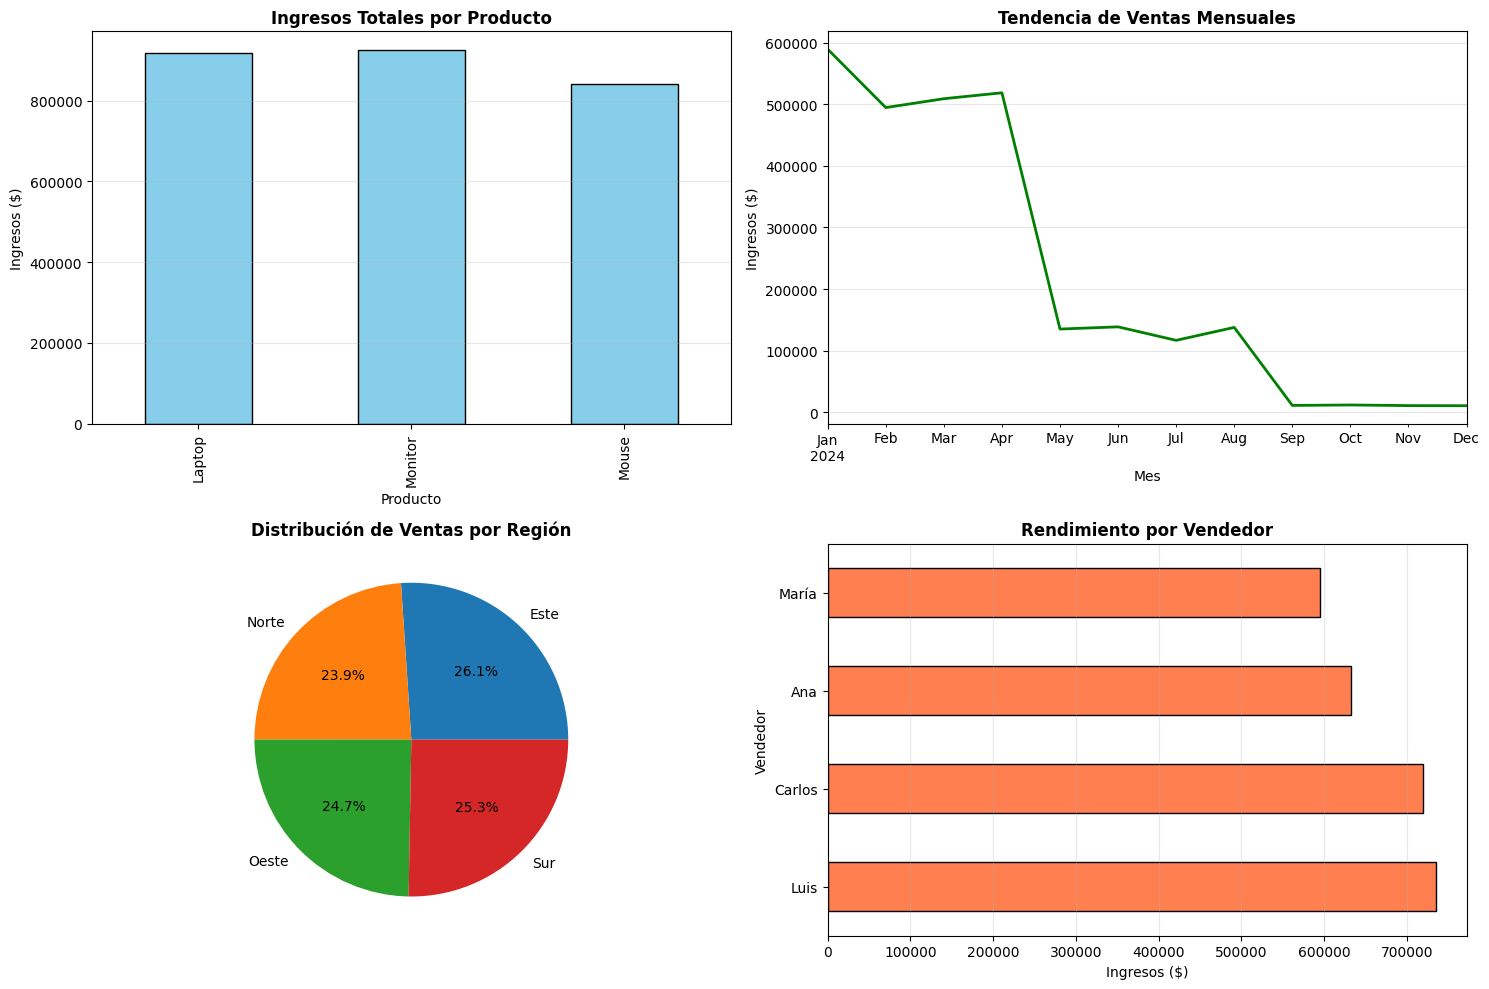


8. RESUMEN EJECUTIVO
Total de ingresos anuales: $2,683,100.00
Promedio diario: $7,350.96
Producto más vendido: Monitor
Región con más ventas: Este
Mejor vendedor: Luis


In [19]:
# Crear dataset completo de ventas
np.random.seed(42)
fechas = pd.date_range('2024-01-01', periods=365, freq='D')

df_completo = pd.DataFrame({
    'Fecha': np.repeat(fechas, 3),
    'Producto': ['Laptop', 'Monitor', 'Mouse'] * 365,
    'Cantidad': np.random.randint(1, 10, 365*3),
    'Precio': np.repeat([1200, 300, 25], 365),
    'Region': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], 365*3),
    'Vendedor': np.random.choice(['Ana', 'Carlos', 'María', 'Luis'], 365*3)
})

# Agregar algunas filas con valores faltantes
df_completo.loc[np.random.choice(df_completo.index, 20), 'Cantidad'] = np.nan

df_completo['Total'] = df_completo['Cantidad'] * df_completo['Precio']

print("=" * 70)
print("ANÁLISIS COMPLETO DE VENTAS ANUALES".center(70))
print("=" * 70)

# 1. Exploración inicial
print("\n1. EXPLORACIÓN INICIAL")
print("=" * 70)
print(f"Dimensiones: {df_completo.shape}")
print(f"\nPrimeras filas:\n{df_completo.head()}")
print(f"\nInformación del dataset:")
print(df_completo.info())

# 2. Limpieza de datos
print("\n2. LIMPIEZA DE DATOS")
print("=" * 70)
print(f"Valores faltantes: {df_completo['Cantidad'].isnull().sum()}")
df_completo['Cantidad'].fillna(df_completo['Cantidad'].median(), inplace=True)
df_completo['Total'] = df_completo['Cantidad'] * df_completo['Precio']
print(f"✓ Valores faltantes imputados con la mediana")

# 3. Análisis por producto
print("\n3. ANÁLISIS POR PRODUCTO")
print("=" * 70)
analisis_producto = df_completo.groupby('Producto').agg({
    'Total': ['sum', 'mean', 'count'],
    'Cantidad': 'sum'
}).round(2)
print(analisis_producto)

# 4. Top vendedores
print("\n4. TOP 5 VENDEDORES")
print("=" * 70)
top_vendedores = df_completo.groupby('Vendedor')['Total'].sum().sort_values(ascending=False)
print(top_vendedores)

# 5. Análisis temporal
print("\n5. ANÁLISIS TEMPORAL (Ventas mensuales)")
print("=" * 70)
df_completo['Mes'] = pd.to_datetime(df_completo['Fecha']).dt.to_period('M')
ventas_mensuales = df_completo.groupby('Mes')['Total'].sum()
print(ventas_mensuales.head(12))

# 6. Pivot table
print("\n6. TABLA DINÁMICA (Producto x Región)")
print("=" * 70)
pivot = pd.pivot_table(df_completo, 
                       values='Total',
                       index='Producto',
                       columns='Region',
                       aggfunc='sum',
                       margins=True)
print(pivot)

# 7. Visualización
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Ventas por producto
ventas_prod = df_completo.groupby('Producto')['Total'].sum()
ventas_prod.plot(kind='bar', ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title('Ingresos Totales por Producto', fontweight='bold')
axes[0,0].set_ylabel('Ingresos ($)')
axes[0,0].grid(axis='y', alpha=0.3)

# Ventas mensuales
ventas_mensuales.plot(ax=axes[0,1], color='green', linewidth=2)
axes[0,1].set_title('Tendencia de Ventas Mensuales', fontweight='bold')
axes[0,1].set_ylabel('Ingresos ($)')
axes[0,1].grid(True, alpha=0.3)

# Distribución por región
ventas_region = df_completo.groupby('Region')['Total'].sum()
ventas_region.plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('Distribución de Ventas por Región', fontweight='bold')
axes[1,0].set_ylabel('')

# Top vendedores
top_vendedores.plot(kind='barh', ax=axes[1,1], color='coral', edgecolor='black')
axes[1,1].set_title('Rendimiento por Vendedor', fontweight='bold')
axes[1,1].set_xlabel('Ingresos ($)')
axes[1,1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Resumen ejecutivo
print("\n8. RESUMEN EJECUTIVO")
print("=" * 70)
print(f"Total de ingresos anuales: ${df_completo['Total'].sum():,.2f}")
print(f"Promedio diario: ${df_completo.groupby('Fecha')['Total'].sum().mean():,.2f}")
print(f"Producto más vendido: {ventas_prod.idxmax()}")
print(f"Región con más ventas: {ventas_region.idxmax()}")
print(f"Mejor vendedor: {top_vendedores.idxmax()}")
print("=" * 70)